# Structural Data Analysis in Python

**From Data to Knowledge**

With python we can perform data operations on large data sets beyond what's  
traditionally thought possible in excel. There is a whole series on data  
science and processing available [here](https://www.youtube.com/watch?v=8GIbOJtUw8w) that will provide further background  
on what's happening within this notebook.

# Extracting the Necessary Data

The best resource for building this out would be AssetWise. It's  
complicated and I'm doing this as a demo.  Tims is super basic to pull all  
values from into a dataframe. So I'm going to demo this concept with TIMs  
for now.

In [1]:
from src.tims_api import fetch_all_features_dataframe
import pandas as pd

In [2]:
LAYER = "https://gis.dot.state.oh.us/arcgis/rest/services/TIMS/Assets/MapServer/5"

# Only records with MAINT_RESP_CD == '01'
df = fetch_all_features_dataframe(
    LAYER,
    where="MAINT_RESP_CD = '01'",
    out_fields="*",            # or a comma-separated list of fields
    return_geometry=False,       # set True if you need geometry
    page_size=500,               # optional tuning
    sleep_between_pages=0.2      # optional throttling
)
print(len(df))

14321


In [3]:
df

,OBJECTID,SFN,STR_LOC_CARRIED,RTE_ON_BRG_CD,DISTRICT,COUNTY_CD,INVENT_SPCL_DSGT,FIPS_CD,INVENT_ON_UND_CD,INVENT_HWY_SYS_CD,...,SURFACE_TYPE,SURFACE_WIDTH,ESAL_TOTAL,PAVE_TYPE,PCR_YEAR,ROADWAY_WIDTH_NBR,created_user,created_date,last_edited_user,last_edited_date
0,7334214,0100072,SR 32,10,09,ADA,,85890,1,3,...,G,48.0,None,FLEX,None,76.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
1,7334215,0100366,SR 32,10,09,ADA,R,48888,1,3,...,G,48.0,None,FLEX,None,76.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
2,7334216,0100544,WHITE PINE RD,40,09,ADA,SR,28196,1,4,...,G,18.0,None,FLEX,None,30.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
3,7334217,0101052,SR 41,10,09,ADA,,76768,1,3,...,G,24.0,None,FLEX,None,28.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
4,7334218,0101117,SR 41,10,09,ADA,,76768,1,3,...,G,24.0,None,FLEX,None,28.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14316,7379503,8802130,SR 67,10,01,WYA,,50106,1,3,...,G,24.0,None,FLEX,None,32.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
14317,7379508,8802548,SR 103 SB USR 23,10,01,WYA,,19246,1,3,...,G,24.0,None,COMP,None,34.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
14318,7379509,8803307,SR 199,10,01,WYA,,70016,1,3,...,G,24.0,None,FLEX,None,44.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000
14319,7379510,8810000,SR 53,10,01,WYA,,78141,1,3,...,G,22.0,None,FLEX,None,32.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000


Now that the data is loaded we can see some general information about the  
data.

In [4]:
print(df.shape)
print(df.dtypes.sort_values())

(14321, 238)
OBJECTID             int64
YR_BUILT             int64
LANES_ON             int64
LANES_UND            int64
DSGT_INSP_FREQ       int64
                     ...  
SCOUR_CRIT_CD       object
FIPS_CD             object
MEDIAN_CD           object
CALC_UNDC           object
APERTURE_ORIG_SW    object
Length: 238, dtype: object


The data has "types" We need to break the columns up into numerical and  
categorical columns for analysis.

In [5]:
# Quick helpers to propose features
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]

In [6]:
# Remove obvious IDs or non-informative columns - These won't help us in analysis
drop_like = {"OBJECTID", "GlobalID", "Shape", "geometry", "SHAPE", "SHAPE_Length", "SHAPE_Area", 'last_edited_date', 'created_date'}
numeric_features = [c for c in numeric_cols if c not in drop_like]
categorical_features = [c for c in cat_cols if c not in drop_like]

In [7]:
# Print the first 10 values in each category to sanity check they're correct
# //TODO - I don't think these are right currently.
numeric_features[:10], categorical_features[:10]

(['LATITUDE_DD',
  'LONGITUDE_DD',
  'MAIN_SPANS',
  'APPRH_SPANS',
  'WEAR_SURF_DT',
  'WEARING_SURF_THCK',
  'PAINT_DT',
  'YR_BUILT',
  'MAJ_RECON_DT',
  'LANES_ON'],
 ['SFN',
  'STR_LOC_CARRIED',
  'RTE_ON_BRG_CD',
  'DISTRICT',
  'COUNTY_CD',
  'INVENT_SPCL_DSGT',
  'FIPS_CD',
  'INVENT_ON_UND_CD',
  'INVENT_HWY_SYS_CD',
  'INVENT_HWY_DSGT_CD'])

# Converting / Normalizing Data

Some features, like anything that stores a year, the year is stored as a  
datetime or timestamp.  This value needs to be converted.  Also when  
analyzing a bridge, traditionally it's more intuitive to analyze them by  
age rather than "Date Built" so we'll convert that into a more friendly  
value.

Note that one of the output of this cell is starting to get pretty useful.  
The average age of the bridge network's wearing surfaces, bridges, paint,  
rehabs.

For more granular analysis, you can filter by district or county prior to  
running these summaries, in that way you can see how various counties and  
districts compare to the average or baseline.

In [8]:
import numpy as np
import pandas as pd

# --- Convert year columns to 'age' features ---
current_year = 2025 # Based on the current date

# Columns that represent a year of an event
year_cols_to_convert = {
    'YR_BUILT': 'BRIDGE_AGE',
    'MAJ_RECON_DT': 'YEARS_SINCE_RECON',
    'PAINT_DT': 'YEARS_SINCE_PAINT',
    'WEAR_SURF_DT': 'YEARS_SINCE_WEAR_SURF'
}

print("Converting timestamp columns to age features...")

for year_col, age_col in year_cols_to_convert.items():
    if year_col in df.columns:
        # Replace 0s or other placeholders with NaN to handle missing values correctly
        df[year_col] = df[year_col].replace(0, np.nan)

        # Convert millisecond timestamp to datetime, then extract year
        year_from_timestamp = pd.to_datetime(df[year_col], unit='ms', errors='coerce').dt.year

        # Calculate age
        df[age_col] = current_year - year_from_timestamp

        # Update the list of numeric features for the processor
        if year_col in numeric_features:
            numeric_features.remove(year_col)
        if age_col not in numeric_features:
            numeric_features.append(age_col)

        print(f"- Converted '{year_col}' to '{age_col}'")

# You can inspect the new columns
print("\nDescription of age features:")
display(df[list(year_cols_to_convert.values())].describe())

Converting timestamp columns to age features...
- Converted 'YR_BUILT' to 'BRIDGE_AGE'
- Converted 'MAJ_RECON_DT' to 'YEARS_SINCE_RECON'
- Converted 'PAINT_DT' to 'YEARS_SINCE_PAINT'
- Converted 'WEAR_SURF_DT' to 'YEARS_SINCE_WEAR_SURF'

Description of age features:


,BRIDGE_AGE,YEARS_SINCE_RECON,YEARS_SINCE_PAINT,YEARS_SINCE_WEAR_SURF
count,14321.000000,2844.000000,5960.000000,10733.000000
mean,47.254870,24.939873,25.548993,18.945682
std,23.268352,14.866231,12.767308,11.437173
min,-6.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,17.000000,10.000000
50%,52.000000,23.000000,26.000000,18.000000
75%,62.000000,32.000000,33.000000,27.000000
max,195.000000,95.000000,115.000000,105.000000


Ha! Terrible AI generated code, how is the minimum bridge age -6 you might  
ask?

In [13]:
df[df['BRIDGE_AGE'] == -6.0]

,OBJECTID,SFN,STR_LOC_CARRIED,RTE_ON_BRG_CD,DISTRICT,COUNTY_CD,INVENT_SPCL_DSGT,FIPS_CD,INVENT_ON_UND_CD,INVENT_HWY_SYS_CD,...,PCR_YEAR,ROADWAY_WIDTH_NBR,created_user,created_date,last_edited_user,last_edited_date,BRIDGE_AGE,YEARS_SINCE_RECON,YEARS_SINCE_PAINT,YEARS_SINCE_WEAR_SURF
4657,7348279,4502078,US 40,10,05,LIC,,25690,1,2,...,None,60.0,TIMS@P31_TIMS,1758890326000,TIMS@P31_TIMS,1758890326000,-6,71.0,26.0,4.0


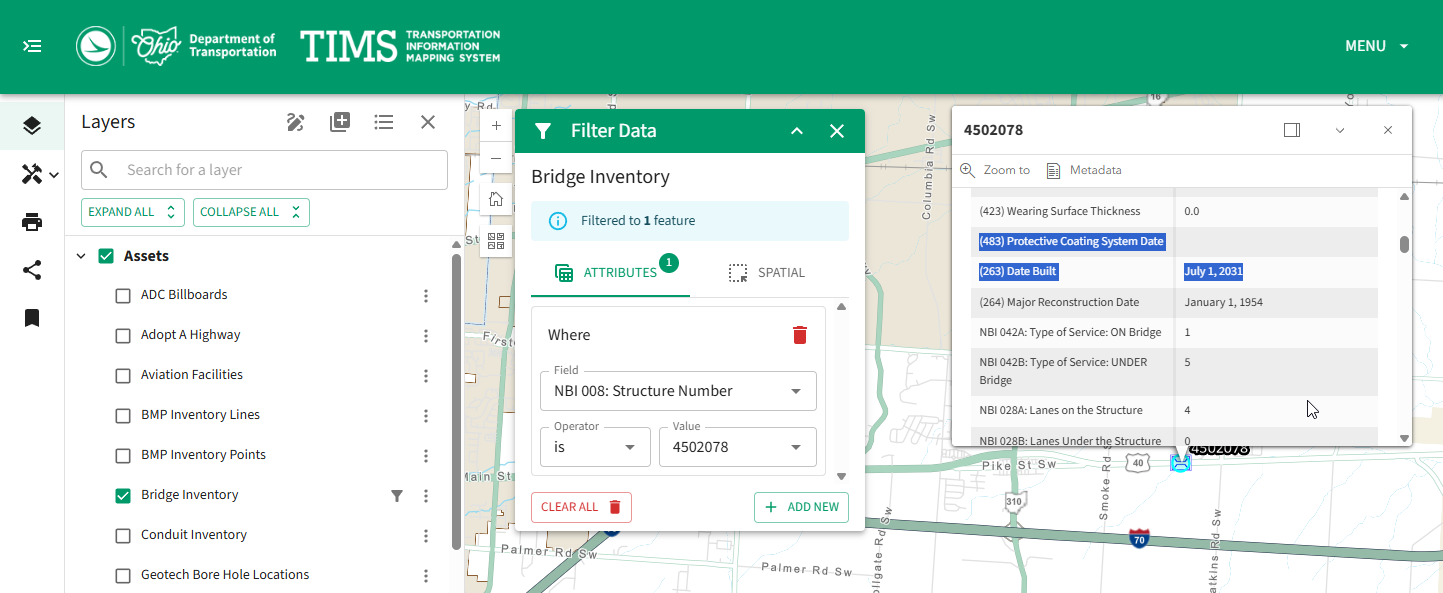

idk, I just got here...

# Where Everything Becomes a Bit Magical

This is the part where we start performing principal component analysis and  
implementing AI. Basically what we're attempting to do is extract what  
makes one bridge "like" another.  We only have 3 axes to plot on, and a lot  
of input parameters for each bridge, so we have to condense these fields  
into singular values or metrics to compare two bridges with each other.

In [9]:
from data_processor import DataProcessor

ID_COL = "OBJECTID"  # adjust if different
NUM_FEATS = numeric_features  # from step 2
CAT_FEATS = categorical_features

proc = DataProcessor(
    numerical_features=NUM_FEATS,
    categorical_features=CAT_FEATS,
    id_column=ID_COL,
    artifacts_dir="artifacts",
)

# Fit and transform
X = proc.fit_transform(df)
feat_names = proc.get_feature_names()
print("Feature matrix:", X.shape)
print("Features (sample):", feat_names[:15])

# Save for reuse (app will load these)
proc.save_artifacts(name="preprocessing")

Feature matrix: (14321, 73412)
Features (sample): ['LATITUDE_DD', 'LONGITUDE_DD', 'MAIN_SPANS', 'APPRH_SPANS', 'WEARING_SURF_THCK', 'LANES_ON', 'LANES_UND', 'INVENT_RTE_ADT', 'NAV_VRT_CLR', 'NAV_HORIZ_CLR', 'MIN_NAV_VRT_CLR', 'INSP_DT', 'DSGT_INSP_FREQ', 'FRACCRIT_INSP_FREQ', 'FRAC_CRIT_INSP_DT']


'artifacts\\preprocessing.joblib'

Now we have a preprocessed feature matrix `X` and the artifacts are saved  
due to the number of categorical features we have, and the nature of  
one-hot encoding. We now have over 73,000 columns in our matrix for each  
bridge.

Long story short, that's too many. We need to find a way to filter out the  
categorical features with "high cardinality". 

In [10]:
# --- Inspect cardinality of categorical features ---
print("Number of unique values for each categorical feature:")
cardinality = df[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

# --- Filter out high-cardinality features ---
# High cardinality can lead to a huge number of features after one-hot encoding.
# Let's set a threshold. Any categorical feature with more than 50 unique values
# is a good candidate for exclusion in this first pass.
CARDINALITY_THRESHOLD = 50
high_cardinality_features = cardinality[cardinality > CARDINALITY_THRESHOLD].index.tolist()

if high_cardinality_features:
    print(f"\nFound {len(high_cardinality_features)} high-cardinality features (>{CARDINALITY_THRESHOLD} unique values).")
    print("Excluding:", high_cardinality_features)

    # Remove them from our feature list
    categorical_features = [c for c in categorical_features if c not in high_cardinality_features]
    print("\nUpdated list of categorical features to be used:")
    print(categorical_features)
else:
    print("\nNo high-cardinality features found.")

Number of unique values for each categorical feature:


SFN                   14321
BIA_REPORT            14321
STR_LOC               12973
INVENT_FEAT            7648
ORIG_PROJ_NBR          6491
                      ...  
SNOOPER_INSP_SW           2
APPRH_STR_DESCR_CD        2
MAINT_RESP_CD             1
created_user              1
last_edited_user          1
Length: 140, dtype: int64


Found 21 high-cardinality features (>50 unique values).
Excluding: ['SFN', 'BIA_REPORT', 'STR_LOC', 'INVENT_FEAT', 'ORIG_PROJ_NBR', 'REMARKS', 'STR_LOC_CARRIED', 'NLFID', 'FIPS_CD', 'MICROFILM_NBR', 'SUFF_RATING', 'HORIZ_CRV_RADIUS', 'STD_DRW_NBR', 'RAT_OPR_LOAD_FACT', 'STREAM_VELOCITY', 'RAT_INV_LOAD_FACT', 'DEDICATED_NME', 'HIST_BUILD_YR', 'COUNTY_CD', 'INVENT_SPCL_DSGT', 'BYPASS_LEN']

Updated list of categorical features to be used:
['RTE_ON_BRG_CD', 'DISTRICT', 'INVENT_ON_UND_CD', 'INVENT_HWY_SYS_CD', 'INVENT_HWY_DSGT_CD', 'INVENT_DIR_SFX_CD', 'MAIN_STR_MTL_CD', 'MAIN_STR_TYPE_CD', 'APPRH_STR_MTL_CD', 'APPRH_STR_TYPE_CD', 'DECK_CD', 'DECK_PROT_EXTL_CD', 'DECK_PROT_INT_CD', 'WEARING_SURF_CD', 'TYPE_SERV1_CD', 'TYPE_SERV2_CD', 'NBIS_LEN_SW', 'INVENT_NHS_CD', 'FUNC_CLAS_CD', 'DFNS_HWY_DSGT_SW', 'PARALLEL_STR_CD', 'DIR_TRAFFIC_CD', 'TEMP_STR_SW', 'DSGT_NATL_NETW_SW', 'TOLL_CD', 'ROUTINE_RESP_CD', 'ROUTINE_RESP_CD_2', 'MAINT_RESP_CD', 'MAINT_RESP_CD_2', 'INSP_RESP_CD', 'INSP_RESP_CD_2

Use the above list on the DataProcessor class again,

In [24]:
ID_COL = "OBJECTID"  # adjust if different
NUM_FEATS = numeric_features  # from step 2
CAT_FEATS = categorical_features

proc = DataProcessor(
    numerical_features=NUM_FEATS,
    categorical_features=CAT_FEATS,
    id_column=ID_COL,
    artifacts_dir="artifacts",
)

# Fit and transform
X = proc.fit_transform(df)
feat_names = proc.get_feature_names()
print("Feature matrix:", X.shape)
print("Features (sample):", feat_names[:15])

# Save for reuse (app will load these)
proc.save_artifacts(name="preprocessing")

Feature matrix: (14321, 1084)
Features (sample): ['LATITUDE_DD', 'LONGITUDE_DD', 'MAIN_SPANS', 'APPRH_SPANS', 'WEARING_SURF_THCK', 'LANES_ON', 'LANES_UND', 'INVENT_RTE_ADT', 'NAV_VRT_CLR', 'NAV_HORIZ_CLR', 'MIN_NAV_VRT_CLR', 'INSP_DT', 'DSGT_INSP_FREQ', 'FRACCRIT_INSP_FREQ', 'FRAC_CRIT_INSP_DT']


'artifacts\\preprocessing.joblib'

1000 fields is much more reasonable.

In [21]:
from sklearn.neighbors import NearestNeighbors
import joblib
import os

# X from the previous step (shape: [n_samples, n_features])
# L2/Euclidean works well with MinMax scaling. You can try cosine as well.
index = NearestNeighbors(n_neighbors=25, metric="euclidean")
index.fit(X)

os.makedirs("artifacts", exist_ok=True)
joblib.dump({
    "nn_index": index,
}, "artifacts/similarity.joblib")

# Keep a copy of source df (with IDs) for lookup
df.to_parquet("artifacts/catalog.parquet", index=False)

In [41]:
import joblib
import pandas as pd
import numpy as np

# Load artifacts once at app startup
art = joblib.load("artifacts/preprocessing.joblib")
proc_pipeline = art["pipeline"]
num_feats = art["numerical_features"]
cat_feats = art["categorical_features"]
id_col = art["id_column"]
feature_names = art["feature_names"]

sim_art = joblib.load("artifacts/similarity.joblib")
index = sim_art["nn_index"]

catalog = pd.read_parquet("artifacts/catalog.parquet")

# Helper: neighbors by existing OBJECTID
def find_neighbors_by_id(object_id: int, k: int = 10) -> pd.DataFrame:
    row = catalog.loc[catalog[id_col] == object_id]
    if row.empty:
        raise ValueError(f"ID {object_id} not found")
    qvec = proc_pipeline.transform(row)[0].astype(np.float32)
    dist, idx = index.kneighbors([qvec], n_neighbors=k)
    result = catalog.iloc[idx[0]].copy()
    result["distance"] = dist[0]
    return result

# Helper: neighbors by ad hoc form input (dict of column->value)
def find_neighbors_by_values(values: dict, k: int = 10) -> pd.DataFrame:
    # Start from medians/modes to fill missing fields, then override with user input
    base = {}
    for c in num_feats:
        base[c] = float(catalog[c].median()) if c in catalog.columns else np.nan
    for c in cat_feats:
        base[c] = catalog[c].mode(dropna=True).iloc[0] if (c in catalog.columns and not catalog[c].mode(dropna=True).empty) else None
    base.update(values)

    qdf = pd.DataFrame([base])
    qvec = proc_pipeline.transform(qdf)[0].astype(np.float32)
    dist, idx = index.kneighbors([qvec], n_neighbors=k)
    result = catalog.iloc[idx[0]].copy()
    result["distance"] = dist[0]
    return result

ArrowKeyError: A type extension with name pandas.period already defined

In [42]:
import os
os.makedirs("artifacts", exist_ok=True)

df.to_parquet("artifacts/catalog.parquet", index=False)  # uses pyarrow by default if installe

ArrowKeyError: A type extension with name pandas.period already defined